Clona Projeto direto do github para facilitar

In [25]:
!git clone https://github.com/carbon-footprint-analysis/carbon-footprint-analysis.git

fatal: destination path 'carbon-footprint-analysis' already exists and is not an empty directory.


importa dados oficiais da empresa de pesquisa energetica e faz EDA + ETL para criar o dataset sintetico ainda !

Abaixo e o data set de consumo por categoria e estado o consumo esta em MW mas abaixo sera convertido para kwh

In [26]:
import pandas as pd

epe = pd.read_csv('/content/carbon-footprint-analysis/data/raw/epe_industrial_consumption_by_state.csv',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [27]:
epe.head()

,Coluna1,DataExcel,SetorIndustrial,UF,Regiao,Consumo,DataVersao
0,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,23/02/2026
1,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,23/02/2026
2,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,23/02/2026
3,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,23/02/2026
4,20251201,01/12/2025,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,23/02/2026


In [28]:
epe['DataExcel'] = pd.to_datetime(epe['DataExcel'], dayfirst=True)

In [29]:
epe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135676 entries, 0 to 135675
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Coluna1          135676 non-null  int64         
 1   DataExcel        135676 non-null  datetime64[ns]
 2   SetorIndustrial  135676 non-null  object        
 3   UF               135676 non-null  object        
 4   Regiao           135676 non-null  object        
 5   Consumo          135676 non-null  float64       
 6   DataVersao       135676 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 7.2+ MB


In [30]:
epe['SetorIndustrial'].unique()

array(['05 - EXTRAÇÃO DE CARVÃO MINERAL',
       '06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL',
       '07 - EXTRAÇÃO DE MINERAIS METÁLICOS',
       '08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS',
       '09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS',
       '10 - FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS',
       '11 - FABRICAÇÃO DE BEBIDAS',
       '12 - FABRICAÇÃO DE PRODUTOS DO FUMO',
       '13 - FABRICAÇÃO DE PRODUTOS TÊXTEIS',
       '14 - CONFECÇÃO DE ARTIGOS DO VESTUÁRIO E ACESSÓRIOS',
       '15 - PREPARAÇÃO DE COUROS E FABRICAÇÃO DE ARTEFATOS DE COURO, ARTIGOS PARA VIAGEM E CALÇADOS',
       '16 - FABRICAÇÃO DE PRODUTOS DE MADEIRA',
       '17 - FABRICAÇÃO DE CELULOSE, PAPEL E PRODUTOS DE PAPEL',
       '18 - IMPRESSÃO E REPRODUÇÃO DE GRAVAÇÕES',
       '19 - FABRICAÇÃO DE COQUE, DE PRODUTOS DERIVADOS DO PETRÓLEO E DE BIOCOMBUSTÍVEIS',
       '20 - FABRICAÇÃO DE PRODUTOS QUÍMICOS',
       '21 - FABRICAÇÃO DE PRODUTOS FARMOQUÍMICOS E FARMACÊUTICOS',
       '22 - FABRICAÇÃO DE PRODUTOS DE

In [31]:
df = epe.copy()

In [32]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [33]:
df_2025 = df[df['year'] == 2025].copy()
df_2025.drop(columns=['DataVersao', 'DataExcel'], inplace=True)

In [34]:
df_2025.head(5)

,Coluna1,SetorIndustrial,UF,Regiao,Consumo,year,month
0,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,AM,Norte,15.000,2025,12
1,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,DF,Centro-Oeste,1.077,2025,12
2,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,ES,Sudeste,23.000,2025,12
3,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MA,Nordeste,39.586,2025,12
4,20251201,05 - EXTRAÇÃO DE CARVÃO MINERAL,MG,Sudeste,20994.000,2025,12


In [35]:
df_grouped = df.groupby('SetorIndustrial')['Consumo'].mean().reset_index()

In [36]:
df_grouped = df_grouped.rename(columns={'Consumo':'Consumo_MWh'})

In [37]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885


In [38]:
df_grouped['Consumo_kWh'] = (df_grouped['Consumo_MWh']) * 1000

In [39]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [40]:
df_grouped.to_csv('media_consumo_indutria_2025.csv')

Abertura do dados oficial consumo mensal por categoria a escala de energia esta em MW mas sera convertido em kwh.

Tambem foi feito o EDA e ETL para criação do dataset sintetico !

In [41]:
import pandas as pd

epe_categoria = pd.read_csv('/content/carbon-footprint-analysis/data/raw/EPE - Dados_abertos_Consumo_Mensal.CSV',
                    encoding='latin-1',
                    sep=';',
                    decimal=',')

In [42]:
epe_categoria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59243 entries, 0 to 59242
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Data            59243 non-null  int64 
 1   DataExcel       59243 non-null  object
 2   UF              59243 non-null  object
 3   Regiao          59243 non-null  object
 4   Sistema         59243 non-null  object
 5   Classe          59243 non-null  object
 6   TipoConsumidor  59243 non-null  object
 7   Consumo         59243 non-null  object
 8   Consumidores    59243 non-null  object
 9   DataVersao      59243 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.5+ MB


In [43]:
epe_categoria['DataExcel'] = pd.to_datetime(epe_categoria['DataExcel'], dayfirst=True)

In [44]:
df = epe_categoria.copy()

In [45]:
df['year'] = df['DataExcel'].dt.year
df['month'] = df['DataExcel'].dt.month

In [46]:
df_2025 = df[df['year'] == 2025]

In [47]:
df_2025['Consumo'] = (
    df_2025['Consumo']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df_2025['Consumidores'] = (
    df_2025['Consumidores']
    .astype(str)
    .str.replace('.', '', regex=False)
    .astype(float)
)

/tmp/ipykernel_13890/3063530973.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumo'] = (
/tmp/ipykernel_13890/3063530973.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Consumidores'] = (


In [48]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 0 to 3327
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            3328 non-null   int64         
 1   DataExcel       3328 non-null   datetime64[ns]
 2   UF              3328 non-null   object        
 3   Regiao          3328 non-null   object        
 4   Sistema         3328 non-null   object        
 5   Classe          3328 non-null   object        
 6   TipoConsumidor  3328 non-null   object        
 7   Consumo         3328 non-null   float64       
 8   Consumidores    3328 non-null   float64       
 9   DataVersao      3328 non-null   object        
 10  year            3328 non-null   int32         
 11  month           3328 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(6)
memory usage: 312.0+ KB


In [49]:
df_2025.head()

,Data,DataExcel,UF,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao,year,month
0,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Comercial,Cativo,175.7,478.0,23/02/2026,2025,12
1,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Industrial,Cativo,7.0,4.0,23/02/2026,2025,12
2,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Outros,Cativo,495.1,382.0,23/02/2026,2025,12
3,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Residencial,Cativo,1266.8,8862.0,23/02/2026,2025,12
4,20251201,2025-12-01,AC,Norte,SISTEMAS ISOLADOS,Rural,Cativo,1181.1,125.0,23/02/2026,2025,12


In [50]:
df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)

/tmp/ipykernel_13890/3578452241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025.drop(columns=['Data', 'DataVersao'], inplace=True)


In [51]:
df_2025 = df_2025.rename(columns={'Consumo':'Consumo_MWh'})

In [52]:
df_simplificado = (
    df_2025
    .groupby('Classe')
    .agg({
        'Consumo_MWh': 'sum',
        'Consumidores': 'sum'
    })
)

df_simplificado['consumo_medio_MWh'] = df_simplificado['Consumo_MWh'] / df_simplificado['Consumidores']

df_simplificado = df_simplificado.sort_values('Consumo_MWh', ascending=False)

In [53]:
df_simplificado['Consumo_kWh'] = (df_simplificado['Consumo_MWh']) * 1000
df_simplificado['consumo_medio_KWh'] = (df_simplificado['consumo_medio_MWh']) * 1000

In [54]:
df_simplificado = df_simplificado[[
    'Consumidores',
    'Consumo_MWh',
    'Consumo_kWh',
    'consumo_medio_MWh',
    'consumo_medio_KWh'
]]

In [55]:
df_simplificado

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [56]:
df_simplificado.to_csv('consumo_medio_categoria_2025.csv')

Verificando a sanidade dos dados

In [57]:
df_grouped.head()

,SetorIndustrial,Consumo_MWh,Consumo_kWh
0,05 - EXTRAÇÃO DE CARVÃO MINERAL,658.978726,6.589787e+05
1,06 - EXTRAÇÃO DE PETRÓLEO E GÁS NATURAL,8514.621995,8.514622e+06
2,07 - EXTRAÇÃO DE MINERAIS METÁLICOS,43036.799370,4.303680e+07
3,08 - EXTRAÇÃO DE MINERAIS NÃO-METÁLICOS,11104.061692,1.110406e+07
4,09 - ATIVIDADES DE APOIO À EXTRAÇÃO DE MINERAIS,739.495885,7.394959e+05


In [58]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SetorIndustrial  37 non-null     object 
 1   Consumo_MWh      37 non-null     float64
 2   Consumo_kWh      37 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1020.0+ bytes


In [59]:
df_simplificado.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [60]:
df_simplificado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, Industrial to Rural
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Consumidores       5 non-null      float64
 1   Consumo_MWh        5 non-null      float64
 2   Consumo_kWh        5 non-null      float64
 3   consumo_medio_MWh  5 non-null      float64
 4   consumo_medio_KWh  5 non-null      float64
dtypes: float64(5)
memory usage: 240.0+ bytes


Criação do consumption_profile.csv

In [61]:
df_profiles = df_simplificado.copy()

In [62]:
df_profiles.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh
Classe,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246


In [63]:
def get_sigma(classe):
    if classe == 'Industrial':
        return 0.6
    elif classe == 'Comercial':
        return 0.4
    elif classe == 'Residencial':
        return 0.3
    else:
        return 0.35

df_profiles['sigma'] = df_profiles.index.map(get_sigma)

In [64]:
map_usage = {
    'Industrial': 'industrial',
    'Comercial': 'commercial',
    'Residencial': 'residential',
    'Rural': 'agriculture',
    'Outros': 'other'
}

df_profiles['usage_type'] = df_profiles.index.map(map_usage)

In [68]:
import numpy as np

df_profiles['mu'] = np.log(df_profiles['consumo_medio_KWh'])

In [69]:
df_final = df_profiles.copy()
df_final['fuel_type'] = 'electric'
df_final['distribution_type'] = 'lognormal'
df_final['param_1'] = df_profiles['mu']
df_final['param_2'] = df_profiles['sigma']
df_final['param_1_name'] = 'mu'
df_final['param_2_name'] = 'sigma'
df_final['unit'] = 'kWh'
df_final['is_energy_based'] = True

In [70]:
df_final.head()

,Consumidores,Consumo_MWh,Consumo_kWh,consumo_medio_MWh,consumo_medio_KWh,sigma,usage_type,mu,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,,,,,,,,
Industrial,5.408760e+06,198858357.9,1.988584e+11,36.765979,36765.979245,0.60,industrial,10.512328,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,1.004322e+09,179155039.1,1.791550e+11,0.178384,178.384142,0.30,residential,5.183939,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,7.399134e+07,102288641.3,1.022886e+11,1.382441,1382.440719,0.40,commercial,7.231606,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,1.059433e+07,51581431.9,5.158143e+10,4.868779,4868.778995,0.35,other,8.490598,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,4.604696e+07,30907605.1,3.090761e+10,0.671219,671.219246,0.35,agriculture,6.509096,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [71]:
df_export = df_final[[
    'usage_type',
    'fuel_type',
    'distribution_type',
    'param_1',
    'param_2',
    'param_1_name',
    'param_2_name',
    'unit',
    'is_energy_based'
]].copy()

In [72]:
df_export.head()

,usage_type,fuel_type,distribution_type,param_1,param_2,param_1_name,param_2_name,unit,is_energy_based
Classe,,,,,,,,,
Industrial,industrial,electric,lognormal,10.512328,0.60,mu,sigma,kWh,True
Residencial,residential,electric,lognormal,5.183939,0.30,mu,sigma,kWh,True
Comercial,commercial,electric,lognormal,7.231606,0.40,mu,sigma,kWh,True
Outros,other,electric,lognormal,8.490598,0.35,mu,sigma,kWh,True
Rural,agriculture,electric,lognormal,6.509096,0.35,mu,sigma,kWh,True


In [73]:
df_export.to_csv('v2_consumption_profiles.csv', index=False)

transformar config em dados sinteticos reais

carergando profile

In [74]:
import pandas as pd
import numpy as np

profiles = pd.read_csv('/content/v2_consumption_profiles.csv')

gerar função

In [75]:
def generate_consumption(profile_row):

    if profile_row['distribution_type'] == 'lognormal':
        mu = profile_row['param_1']
        sigma = profile_row['param_2']

        value = np.random.lognormal(mu, sigma)

        # LIMITADOR
        max_value = 10 * np.exp(mu)
        value = min(value, max_value)

        return value

    else:
        raise ValueError("Distribuição não suportada")

gerar evento

In [76]:
usage_probs = {
    'residential': 0.6,
    'commercial': 0.2,
    'industrial': 0.1,
    'agriculture': 0.05,
    'other': 0.05
}

In [77]:
def generate_event(profiles):

    weights = profiles['usage_type'].map(usage_probs)

    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption
    }

gerar dataset

In [78]:
def generate_dataset(n, profiles):
    data = []

    for _ in range(n):
        event = generate_event(profiles)
        data.append(event)

    return pd.DataFrame(data)

test

In [79]:
df = generate_dataset(10000, profiles)

In [80]:
df.head()

,usage_type,fuel_type,energy_kwh
0,residential,electric,201.812281
1,commercial,electric,1771.634445
2,residential,electric,201.510230
3,residential,electric,114.696661
4,agriculture,electric,915.047733


In [81]:
df.to_csv('df_gerado_teste.csv')

In [82]:
df['usage_type'].value_counts(normalize=True)

,proportion
usage_type,
residential,0.5962
commercial,0.2007
industrial,0.1013
agriculture,0.0532
other,0.0486


In [83]:
df.groupby('usage_type')['energy_kwh'].describe()

,count,mean,std,min,25%,50%,75%,max
usage_type,,,,,,,,
agriculture,532.0,708.949882,271.286686,213.272768,518.891935,652.906230,851.100649,2098.232010
commercial,2007.0,1504.650248,612.668288,333.898998,1058.139298,1413.942060,1821.027651,4743.349107
industrial,1013.0,41902.232496,25786.253731,5358.724547,24370.194742,36281.578029,52347.247779,251551.545247
other,486.0,5038.569786,1776.706865,2208.882979,3830.390498,4663.370372,5881.847197,15611.800603
residential,5962.0,187.695092,57.539166,68.373963,146.679418,179.529142,219.995832,546.092326


In [84]:
df['energy_kwh'].max()

251551.54524686796

In [85]:
(df['energy_kwh'] < 0).sum()

np.int64(0)

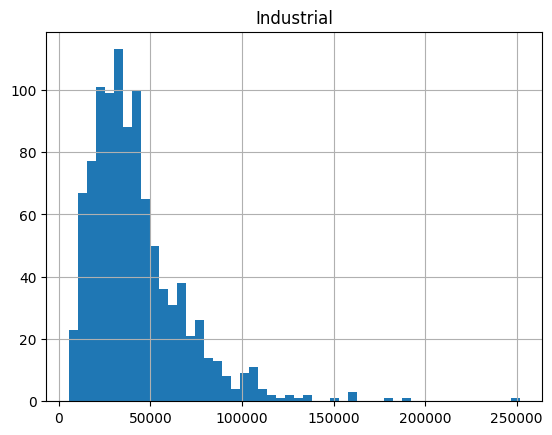

In [86]:
import matplotlib.pyplot as plt

df[df['usage_type']=='industrial']['energy_kwh'].hist(bins=50)
plt.title('Industrial')
plt.show()

criando o energy _source_distribution.csv

In [87]:
df_aneel = pd.read_csv('/content/carbon-footprint-analysis/data/raw/aneel_generation.csv',
                       encoding='latin-1',
                       sep=';',
                       decimal=',')

In [88]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   DatGeracaoConjuntoDados  495 non-null    object 
 1   SigTipoGeracao           495 non-null    object 
 2   QtdUsinasPeriodo         495 non-null    int64  
 3   MdaPotenciaInstaladaKW   495 non-null    float64
 4   MesReferencia            495 non-null    int64  
 5   AnoReferencia            495 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 23.3+ KB


In [89]:
df_aneel.head()

,DatGeracaoConjuntoDados,SigTipoGeracao,QtdUsinasPeriodo,MdaPotenciaInstaladaKW,MesReferencia,AnoReferencia
0,2026-03-01,CGH,0,0.0,12,2001
1,2026-03-01,EOL,7,21000.0,12,2001
2,2026-03-01,PCH,303,855000.0,12,2001
3,2026-03-01,UFV,0,0.0,12,2001
4,2026-03-01,UHE,133,61554000.0,12,2001


In [90]:
df_aneel['AnoReferencia'].unique()

array([2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025])

In [91]:
df_aneel = df_aneel[df_aneel['AnoReferencia']==2025]

In [92]:
df_aneel['SigTipoGeracao'].unique()

array(['EOL', 'CGH', 'UFV', 'PCH', 'UHE', 'UTE', 'UTN'], dtype=object)

In [93]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum()

In [94]:
df_grouped.head()

,MdaPotenciaInstaladaKW
SigTipoGeracao,
CGH,3.577829e+06
EOL,1.360294e+08
PCH,2.382840e+07
UFV,7.451254e+07
UHE,4.128522e+08


converter para probabilidade

In [95]:
df_dist = df_grouped / df_grouped.sum()

transformar e dataframe

In [99]:
df_dist.info()

<class 'pandas.core.series.Series'>
Index: 7 entries, CGH to UTN
Series name: MdaPotenciaInstaladaKW
Non-Null Count  Dtype  
--------------  -----  
7 non-null      float64
dtypes: float64(1)
memory usage: 412.0+ bytes


In [100]:
df_grouped = df_aneel.groupby('SigTipoGeracao')['MdaPotenciaInstaladaKW'].sum().reset_index()

df_grouped.columns = ['energy_source', 'total_generation']

In [101]:
df_grouped['probability'] = df_grouped['total_generation'] / df_grouped['total_generation'].sum()

df_dist = df_grouped[['energy_source', 'probability']]
df_dist = df_dist.copy()

In [102]:
df_dist.head()

,energy_source,probability
0,CGH,0.004194
1,EOL,0.159455
2,PCH,0.027932
3,UFV,0.087344
4,UHE,0.483948


In [103]:
df_dist['probability'].sum()

np.float64(1.0)

In [104]:
map_sources = {
    'UHE': 'hydro',      # Hidrelétrica grande
    'PCH': 'hydro',      # Pequena central hidrelétrica
    'CGH': 'hydro',      # Central geradora hidráulica

    'EOL': 'wind',       # Eólica

    'UFV': 'solar',      # Solar fotovoltaica

    # se aparecer depois:
    'UTE': 'thermal',    # termoelétrica (genérico)
    'UTN': 'nuclear',    # nuclear
}
df_dist['energy_source'] = df_dist['energy_source'].map(map_sources)

In [105]:
df_dist = df_dist.groupby('energy_source')['probability'].sum().reset_index()

In [106]:
df_dist['probability'] = df_dist['probability'] / df_dist['probability'].sum()

In [107]:
df_dist = df_dist.sort_values('probability', ascending=False)

In [108]:
df_dist

,energy_source,probability
0,hydro,0.516074
3,thermal,0.227796
4,wind,0.159455
2,solar,0.087344
1,nuclear,0.009331


In [109]:
df_dist.to_csv('energy _source_distribution.csv')

Inserir a emissão co2

In [111]:
emission_factors = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy_source_emission_factors.csv')

In [113]:
def calculate_emission(energy_kwh, energy_source, emission_df):

    row = emission_df.loc[
        emission_df['energy_source'] == energy_source
    ]

    if row.empty:
        raise ValueError(f"Fonte não encontrada: {energy_source}")

    factor = row['emission_factor'].values[0]

    return energy_kwh * factor

In [114]:
def sample_energy_source(dist_df):
    return dist_df.sample(1, weights=dist_df['probability']).iloc[0]['energy_source']

In [115]:
def generate_event(profiles, energy_dist, emission_df):

    weights = profiles['usage_type'].map(usage_probs)
    row = profiles.sample(1, weights=weights).iloc[0]

    consumption = generate_consumption(row)

    energy_source = sample_energy_source(energy_dist)

    co2 = calculate_emission(consumption, energy_source, emission_df)

    return {
        'usage_type': row['usage_type'],
        'fuel_type': row['fuel_type'],
        'energy_kwh': consumption,
        'energy_source': energy_source,
        'co2_emission': co2
    }

In [116]:
import pandas as pd
profiles = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_consumption_profiles.csv')

energy_dist = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy _source_distribution.csv')

emission_df = pd.read_csv('/content/carbon-footprint-analysis/data/external/v2_energy_source_emission_factors.csv')

In [117]:
event = generate_event(profiles, energy_dist, emission_df)
event

{'usage_type': 'residential',
 'fuel_type': 'electric',
 'energy_kwh': 183.81999958255037,
 'energy_source': 'thermal',
 'co2_emission': np.float64(110.29199974953022)}

In [119]:
def generate_dataset(n, profiles, energy_dist, emission_df):
    data = []

    for _ in range(n):
        event = generate_event(profiles, energy_dist, emission_df)
        data.append(event)

    return pd.DataFrame(data)

In [120]:
df = generate_dataset(10000, profiles, energy_dist, emission_df)
df.describe()

,energy_kwh,co2_emission
count,10000.000000,10000.000000
mean,5105.969987,688.528435
std,15948.756459,4103.576445
min,65.356082,0.748994
25%,167.473022,3.380665
50%,239.337933,13.484100
75%,1394.994348,108.571726
max,266654.963100,81762.526965


In [121]:
df.head()

,usage_type,fuel_type,energy_kwh,energy_source,co2_emission
0,agriculture,electric,672.862760,hydro,13.457255
1,commercial,electric,2062.356043,hydro,41.247121
2,residential,electric,168.707136,wind,1.687071
3,residential,electric,296.113403,hydro,5.922268
4,residential,electric,134.420832,thermal,80.652499
